# Modelo 2 — Lei de Okun: Relação de Nível com o Hiato do Produto
## Fase 3 da Análise Econométrica (TCC - UFRPE)

Este notebook estima a relação entre o **nível** da taxa de desemprego e o **hiato do produto**,
testando três medidas alternativas de hiato extraídas do PIB dessazonalizado via filtros estatísticos:

| Filtro | Referência | Características |
|--------|-----------|-----------------|
| **HP** (Hodrick-Prescott, λ=1600) | Hodrick & Prescott (1997) | Padrão na literatura macro; sensível aos extremos da série |
| **Hamilton** (h=8, p=4) | Hamilton (2018) | Moderno; evita distorções nos extremos via regressão |
| **CF** (Christiano-Fitzgerald) | Christiano & Fitzgerald (2003) | Bandpass assimétrico; preserva frequências de ciclo de negócios |

> **Nota:** FGV/IBRE e FMI não disponibilizam séries de hiato para o Brasil via API pública com
> frequência trimestral. A comparação entre os três filtros cobre o espectro metodológico principal
> da literatura e permite avaliar a robustez do coeficiente de Okun à escolha do filtro.

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.filters.hp_filter import hpfilter
from statsmodels.tsa.filters.cf_filter import cffilter
from statsmodels.stats.diagnostic import het_white, acorr_breusch_godfrey
from statsmodels.stats.stattools import jarque_bera   # retorna (stat, p, skew, kurt)
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

# ── PALETA E PERÍODOS DE METODOLOGIA ──────────────────────────────────────────
COR_PRINCIPAL   = '#2563EB'
COR_HAMILTN     = '#059669'
COR_CF          = '#D97706'
COR_FITTED      = '#DC2626'
COR_ZERO        = '#6B7280'
ALPHA_SHADE     = 0.08

PERIODOS_MET = [
    ('1994-03-31', '2002-03-31', '#FBBF24', 'PME Antiga'),
    ('2002-03-31', '2012-03-31', '#86EFAC', 'PME Nova'),
    ('2012-03-31', '2025-01-01', '#93C5FD', 'PNADc'),
]

def sombrear_periodos(ax):
    for ini, fim, cor, label in PERIODOS_MET:
        ax.axvspan(pd.Timestamp(ini), pd.Timestamp(fim),
                   alpha=ALPHA_SHADE, color=cor, label=label)

# ── CARREGAMENTO DOS DADOS ────────────────────────────────────────────────────
pib_df        = pd.read_pickle('../dados/pib_tratado.pkl')
desemprego_df = pd.read_pickle('../dados/desemprego_tratado.pkl')

df = pib_df.join(desemprego_df[['desemprego']], how='inner')
df = df.rename(columns={'desemprego': 'u_t'})
df = df.loc['1996-01-01':'2024-12-31'].copy()
df = df.dropna(subset=['ln_pib', 'u_t'])

print(f"Dataset: {len(df)} observações  |  {df.index[0].date()} → {df.index[-1].date()}")
print(df[['u_t', 'ln_pib', 'crescimento_pib']].describe().round(3))


Dataset: 116 observações  |  1996-03-31 → 2024-12-31
           u_t   ln_pib  crescimento_pib
count  116.000  116.000          115.000
mean     9.154   12.450            0.568
std      2.461    0.199            1.630
min      4.843   12.075           -9.306
25%      7.200   12.243           -0.021
50%      8.503   12.538            0.836
75%     11.425   12.616            1.289
max     14.633   12.730            7.622


In [2]:
# ── FILTRO HP (λ = 1600) ─────────────────────────────────────────────────────
ciclo_hp, tendencia_hp = hpfilter(df['ln_pib'], lamb=1600)
df['hiato_hp']  = ciclo_hp * 100    # em % do PIB potencial
df['trend_hp']  = tendencia_hp

# ── FILTRO HAMILTON (h=8 trimestres, p=4 defasagens) ─────────────────────────
def hamilton_filter(series, h=8, p=4):
    """Hamilton (2018): regride y_t sobre [1, y_{t-h}, ..., y_{t-h-p+1}].
    O hiato é o resíduo da projeção — evita distorções nos extremos do HP."""
    s = series.copy()
    X = pd.DataFrame({'const': 1.0}, index=s.index)
    for i in range(p):
        X[f'lag{h+i}'] = s.shift(h + i)
    valid = X.dropna().index
    modelo = sm.OLS(s.loc[valid], X.loc[valid]).fit()
    fitted = pd.Series(np.nan, index=s.index)
    fitted.loc[valid] = modelo.fittedvalues
    return (s - fitted) * 100, fitted

ciclo_ham, tendencia_ham = hamilton_filter(df['ln_pib'])
df['hiato_hamilton'] = ciclo_ham
df['trend_hamilton'] = tendencia_ham

# ── FILTRO CHRISTIANO-FITZGERALD (bandpass 6-32 trimestres) ──────────────────
cycle_cf, trend_cf = cffilter(df['ln_pib'], low=6, high=32, drift=True)
df['hiato_cf']   = cycle_cf * 100
df['trend_cf']   = trend_cf

# Resumo
print("Resumo dos hiatos computados:")
hiatos = df[['hiato_hp', 'hiato_hamilton', 'hiato_cf']].dropna()
print(hiatos.describe().round(3))
print(f"\nObservações com todos os hiatos válidos: {len(hiatos)}")

Resumo dos hiatos computados:
       hiato_hp  hiato_hamilton  hiato_cf
count   105.000         105.000   105.000
mean     -0.056           0.000    -0.034
std       1.845           4.364     1.552
min     -10.301         -12.184    -3.827
25%      -0.949          -2.041    -0.841
50%       0.340           0.350     0.254
75%       1.067           2.922     0.897
max       3.484          11.208     3.728

Observações com todos os hiatos válidos: 105


fig_10a salva


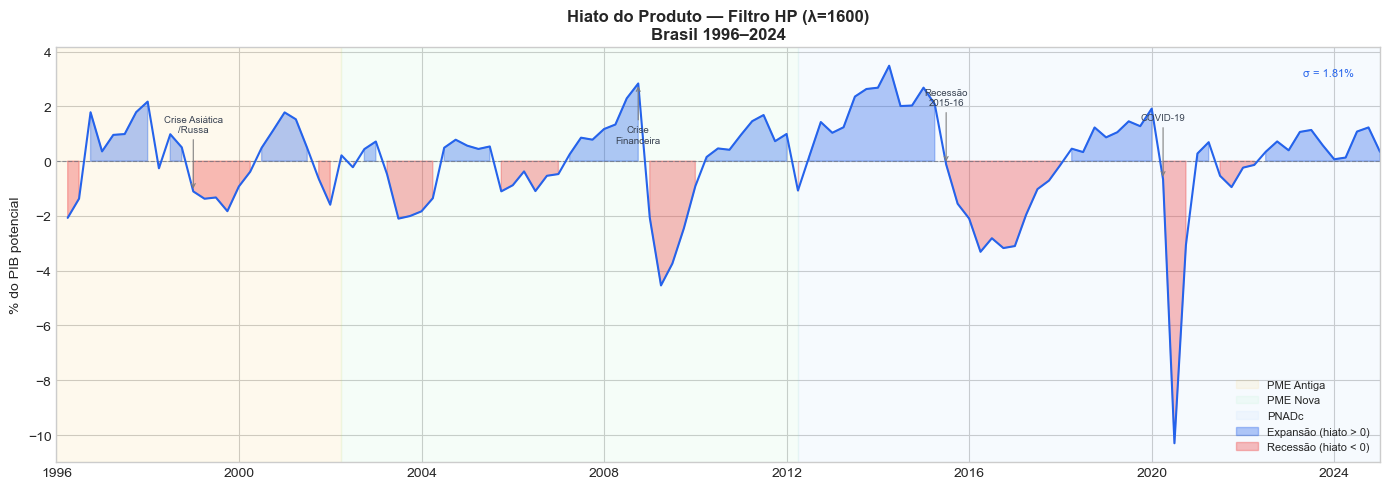

In [16]:
# ── GRAFICO 10a: HIATO HP (Hodrick-Prescott, λ=1600) ─────────────────────────
serie = df['hiato_hp'].dropna()
desvio = serie.std()
offset = desvio * 1.2

fig, ax = plt.subplots(figsize=(14, 5))
sombrear_periodos(ax)
ax.axhline(0, color=COR_ZERO, linewidth=0.8, linestyle='--', alpha=0.7)
ax.fill_between(serie.index, serie, 0,
                where=(serie >= 0), alpha=0.35, color=COR_PRINCIPAL, label='Expansão (hiato > 0)')
ax.fill_between(serie.index, serie, 0,
                where=(serie < 0),  alpha=0.35, color='#EF4444', label='Recessão (hiato < 0)')
ax.plot(serie.index, serie, color=COR_PRINCIPAL, linewidth=1.5)

eventos = [
    ('1998-12-31', 'Crise Asiática\n/Russa'),
    ('2008-09-30', 'Crise\nFinanceira'),
    ('2015-06-30', 'Recessão\n2015-16'),
    ('2020-03-31', 'COVID-19'),
]
for dt, txt in eventos:
    ts = pd.Timestamp(dt)
    if ts in serie.index:
        val = serie.loc[ts]
        ax.annotate(txt, xy=(ts, val),
                    xytext=(ts, val + (offset if val < 0 else -offset)),
                    fontsize=7, ha='center', color='#374151',
                    arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

ax.set_ylabel('% do PIB potencial', fontsize=10)
ax.set_title('Hiato do Produto — Filtro HP (λ=1600)\nBrasil 1996–2024',
             fontsize=12, fontweight='bold')
ax.set_xlim(pd.Timestamp('1996-01-01'), pd.Timestamp('2024-12-31'))
ax.legend(fontsize=8, loc='lower right')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(4))
ax.text(0.98, 0.95, f'σ = {desvio:.2f}%', transform=ax.transAxes,
        fontsize=8, color=COR_PRINCIPAL, va='top', ha='right')

plt.tight_layout()
plt.savefig('../figuras/fase3_modelo2/fig_10a_hiato_hp.png', dpi=150, bbox_inches='tight')
print('fig_10a salva')
plt.show()

fig_10b salva


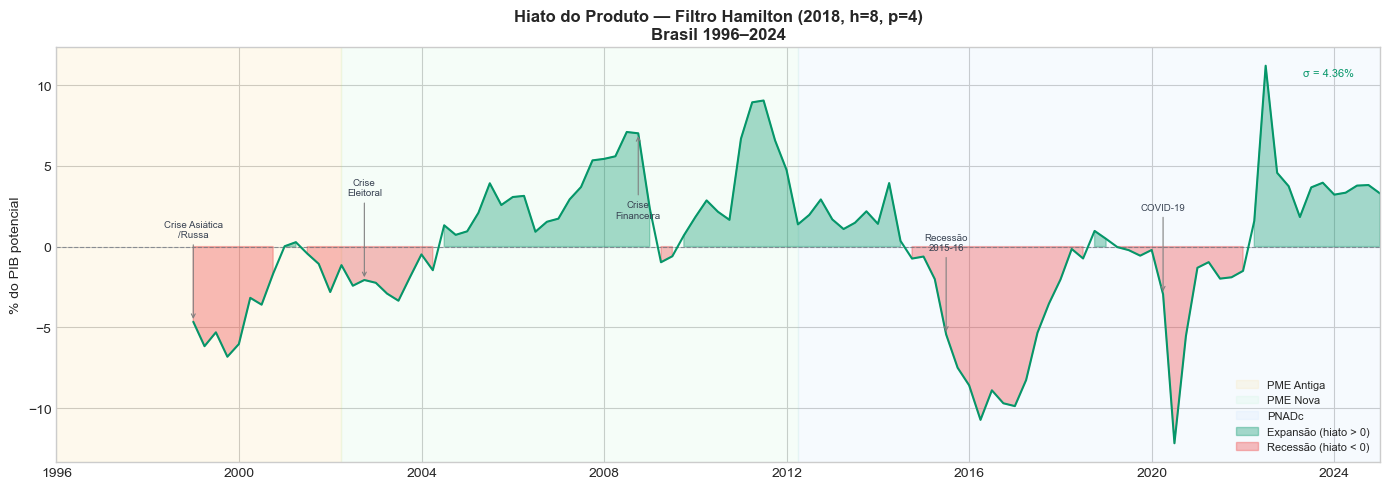

In [4]:
# ── GRAFICO 10b: HIATO HAMILTON (2018, h=8, p=4) ─────────────────────────────
serie = df['hiato_hamilton'].dropna()
desvio = serie.std()
offset = desvio * 1.2

fig, ax = plt.subplots(figsize=(14, 5))
sombrear_periodos(ax)
ax.axhline(0, color=COR_ZERO, linewidth=0.8, linestyle='--', alpha=0.7)
ax.fill_between(serie.index, serie, 0,
                where=(serie >= 0), alpha=0.35, color=COR_HAMILTN, label='Expansão (hiato > 0)')
ax.fill_between(serie.index, serie, 0,
                where=(serie < 0),  alpha=0.35, color='#EF4444', label='Recessão (hiato < 0)')
ax.plot(serie.index, serie, color=COR_HAMILTN, linewidth=1.5)

eventos = [
    ('1998-12-31', 'Crise Asiática\n/Russa'),
    ('2002-09-30', 'Crise\nEleitoral'),
    ('2008-09-30', 'Crise\nFinanceira'),
    ('2015-06-30', 'Recessão\n2015-16'),
    ('2020-03-31', 'COVID-19'),
]
for dt, txt in eventos:
    ts = pd.Timestamp(dt)
    if ts in serie.index:
        val = serie.loc[ts]
        ax.annotate(txt, xy=(ts, val),
                    xytext=(ts, val + (offset if val < 0 else -offset)),
                    fontsize=7, ha='center', color='#374151',
                    arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

ax.set_ylabel('% do PIB potencial', fontsize=10)
ax.set_title('Hiato do Produto — Filtro Hamilton (2018, h=8, p=4)\nBrasil 1996–2024',
             fontsize=12, fontweight='bold')
ax.set_xlim(pd.Timestamp('1996-01-01'), pd.Timestamp('2024-12-31'))
ax.legend(fontsize=8, loc='lower right')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(4))
ax.text(0.98, 0.95, f'σ = {desvio:.2f}%', transform=ax.transAxes,
        fontsize=8, color=COR_HAMILTN, va='top', ha='right')

plt.tight_layout()
plt.savefig('../figuras/fase3_modelo2/fig_10b_hiato_hamilton.png', dpi=150, bbox_inches='tight')
print('fig_10b salva')
plt.show()

fig_10c salva


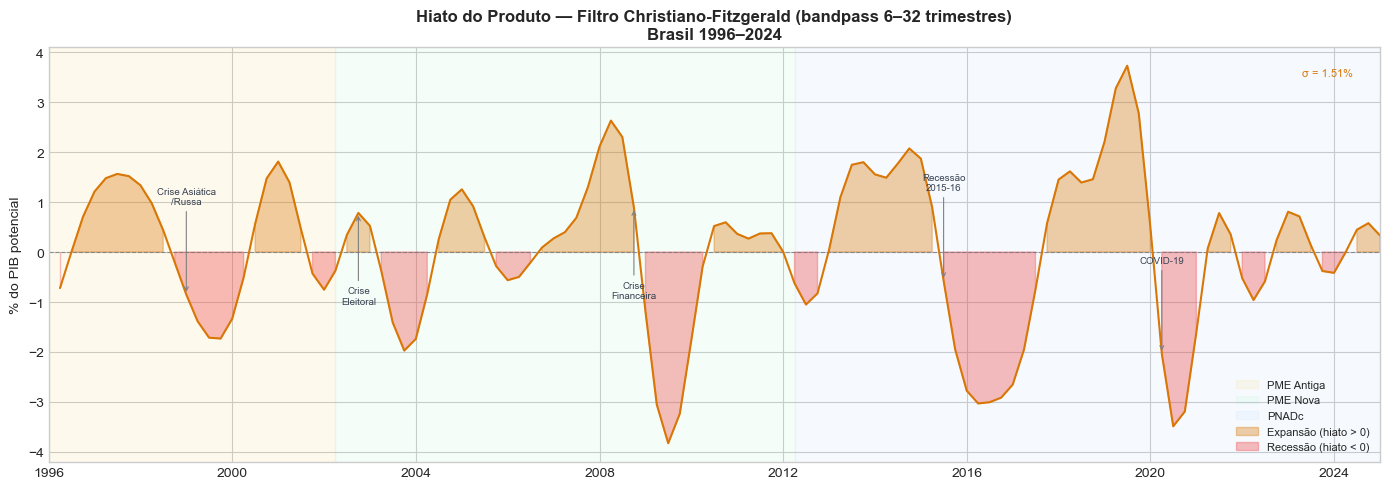

In [5]:
# ── GRAFICO 10c: HIATO CF (Christiano-Fitzgerald, bandpass 6–32 trimestres) ──
serie = df['hiato_cf'].dropna()
desvio = serie.std()
offset = desvio * 1.2

fig, ax = plt.subplots(figsize=(14, 5))
sombrear_periodos(ax)
ax.axhline(0, color=COR_ZERO, linewidth=0.8, linestyle='--', alpha=0.7)
ax.fill_between(serie.index, serie, 0,
                where=(serie >= 0), alpha=0.35, color=COR_CF, label='Expansão (hiato > 0)')
ax.fill_between(serie.index, serie, 0,
                where=(serie < 0),  alpha=0.35, color='#EF4444', label='Recessão (hiato < 0)')
ax.plot(serie.index, serie, color=COR_CF, linewidth=1.5)

eventos = [
    ('1998-12-31', 'Crise Asiática\n/Russa'),
    ('2002-09-30', 'Crise\nEleitoral'),
    ('2008-09-30', 'Crise\nFinanceira'),
    ('2015-06-30', 'Recessão\n2015-16'),
    ('2020-03-31', 'COVID-19'),
]
for dt, txt in eventos:
    ts = pd.Timestamp(dt)
    if ts in serie.index:
        val = serie.loc[ts]
        ax.annotate(txt, xy=(ts, val),
                    xytext=(ts, val + (offset if val < 0 else -offset)),
                    fontsize=7, ha='center', color='#374151',
                    arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

ax.set_ylabel('% do PIB potencial', fontsize=10)
ax.set_title('Hiato do Produto — Filtro Christiano-Fitzgerald (bandpass 6–32 trimestres)\nBrasil 1996–2024',
             fontsize=12, fontweight='bold')
ax.set_xlim(pd.Timestamp('1996-01-01'), pd.Timestamp('2024-12-31'))
ax.legend(fontsize=8, loc='lower right')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(4))
ax.text(0.98, 0.95, f'σ = {desvio:.2f}%', transform=ax.transAxes,
        fontsize=8, color=COR_CF, va='top', ha='right')

plt.tight_layout()
plt.savefig('../figuras/fase3_modelo2/fig_10c_hiato_cf.png', dpi=150, bbox_inches='tight')
print('fig_10c salva')
plt.show()

In [6]:
# Correlação entre os três hiatos — verifica consistência
hiatos = df[['hiato_hp', 'hiato_hamilton', 'hiato_cf']].dropna()
corr = hiatos.corr()
print("Matriz de correlação entre os hiatos:")
print(corr.round(3))
print()
print("Correlação HP × Hamilton:", f"{corr.loc['hiato_hp','hiato_hamilton']:.3f}")
print("Correlação HP × CF:      ", f"{corr.loc['hiato_hp','hiato_cf']:.3f}")
print("Correlação Hamilton × CF:", f"{corr.loc['hiato_hamilton','hiato_cf']:.3f}")

Matriz de correlação entre os hiatos:
                hiato_hp  hiato_hamilton  hiato_cf
hiato_hp           1.000           0.633     0.808
hiato_hamilton     0.633           1.000     0.515
hiato_cf           0.808           0.515     1.000

Correlação HP × Hamilton: 0.633
Correlação HP × CF:       0.808
Correlação Hamilton × CF: 0.515


Step dummies criadas:
  d_PMENova = 1 a partir de 2002-T1 (92 observações = 1)
  d_PNADc   = 1 a partir de 2012-T1 (52 observações = 1)
fig_10b salva


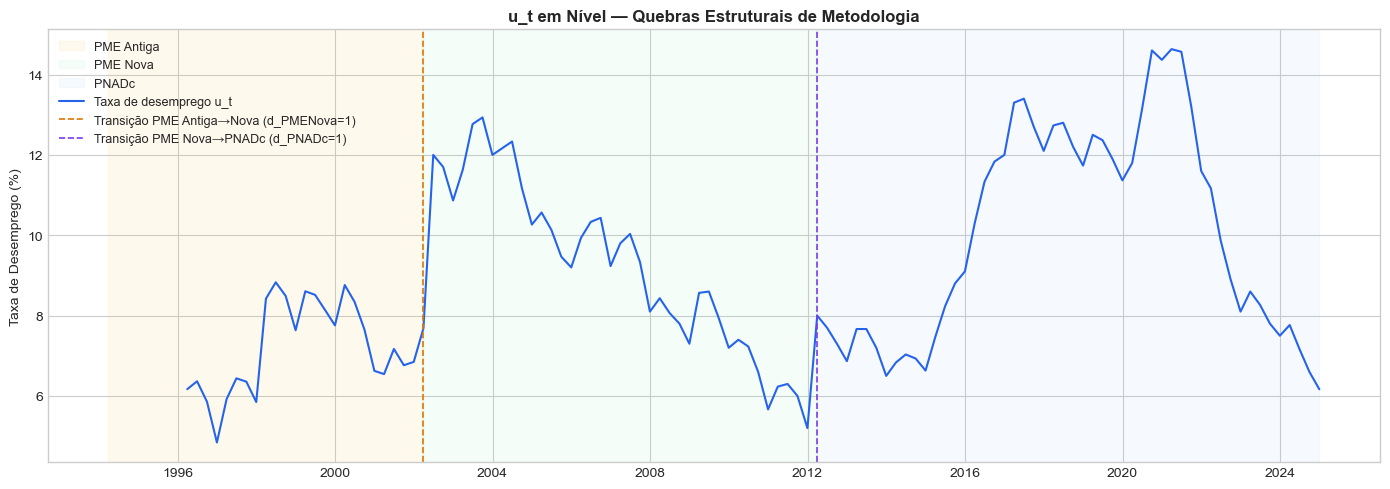

In [7]:
# ── STEP DUMMIES PARA O MODELO DE NÍVEL ──────────────────────────────────────
# No modelo em NÍVEL (diferente do modelo em 1ª diferença), as quebras metodológicas
# criam shifts permanentes na série u_t. Precisamos de step dummies (0→1 permanente).

df['d_PMENova'] = (df.index >= '2002-03-31').astype(float)  # PME Nova: T1-2002 em diante
df['d_PNADc']   = (df.index >= '2012-03-31').astype(float)  # PNADc:    T1-2012 em diante

print("Step dummies criadas:")
print(f"  d_PMENova = 1 a partir de 2002-T1 ({df['d_PMENova'].sum():.0f} observações = 1)")
print(f"  d_PNADc   = 1 a partir de 2012-T1 ({df['d_PNADc'].sum():.0f} observações = 1)")

# Visualizar o efeito das dummies na série u_t
fig, ax = plt.subplots(figsize=(14, 5))
sombrear_periodos(ax)
ax.plot(df.index, df['u_t'], color=COR_PRINCIPAL, linewidth=1.5, label='Taxa de desemprego u_t')
ax.axvline(pd.Timestamp('2002-03-31'), color='#D97706', linestyle='--', linewidth=1.2,
           label='Transição PME Antiga→Nova (d_PMENova=1)')
ax.axvline(pd.Timestamp('2012-03-31'), color='#7C3AED', linestyle='--', linewidth=1.2,
           label='Transição PME Nova→PNADc (d_PNADc=1)')
ax.set_ylabel('Taxa de Desemprego (%)', fontsize=10)
ax.set_title('u_t em Nível — Quebras Estruturais de Metodologia', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(4))
plt.tight_layout()
plt.savefig('../figuras/fase3_modelo2/fig_10b_ut_nivel_com_quebras.png', dpi=150, bbox_inches='tight')
print("fig_10b salva")
plt.show()

In [8]:
# ── FUNÇÃO AUXILIAR: estima e resume o modelo de hiato ───────────────────────
def estimar_modelo_hiato(hiato_col, label):
    """OLS com HAC: u_t = β₀ + β₁·hiato + γ₁·d_PMENova + γ₂·d_PNADc + ε_t"""
    df_m = df[['u_t', hiato_col, 'd_PMENova', 'd_PNADc']].dropna().copy()

    Y = df_m['u_t']
    X = sm.add_constant(df_m[[hiato_col, 'd_PMENova', 'd_PNADc']])
    modelo = sm.OLS(Y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 4})

    # Testes de diagnóstico
    resid = modelo.resid
    jb_stat, jb_p, _, _ = jarque_bera(resid)
    bg_stat, bg_p, _, _  = acorr_breusch_godfrey(modelo, nlags=4)
    white_stat, white_p, _, _ = het_white(resid, modelo.model.exog)

    resultado = {
        'label':    label,
        'n':        len(df_m),
        'beta1':    modelo.params[hiato_col],
        'p_beta1':  modelo.pvalues[hiato_col],
        'beta0':    modelo.params['const'],
        'p_beta0':  modelo.pvalues['const'],
        'gamma1':   modelo.params['d_PMENova'],
        'p_gamma1': modelo.pvalues['d_PMENova'],
        'gamma2':   modelo.params['d_PNADc'],
        'p_gamma2': modelo.pvalues['d_PNADc'],
        'r2_adj':   modelo.rsquared_adj,
        'aic':      modelo.aic,
        'bic':      modelo.bic,
        'jb_p':     jb_p,
        'bg_p':     bg_p,
        'white_p':  white_p,
        'modelo':   modelo,
        'df_m':     df_m,
    }

    print(f"\n{'='*60}")
    print(f"MODELO HIATO — {label}")
    print(f"{'='*60}")
    print(modelo.summary())
    print(f"\nJarque-Bera p = {jb_p:.3f} {'✓' if jb_p>0.05 else '✗'}")
    print(f"Breusch-Godfrey p = {bg_p:.3f} (corrigido HAC)")
    print(f"White p = {white_p:.3f} {'✓' if white_p>0.05 else '✗'}")
    return resultado


MODELO HIATO — HP (λ=1600)
                            OLS Regression Results                            
Dep. Variable:                    u_t   R-squared:                       0.321
Model:                            OLS   Adj. R-squared:                  0.303
Method:                 Least Squares   F-statistic:                     13.54
Date:                Mon, 11 May 2026   Prob (F-statistic):           1.34e-07
Time:                        10:39:17   Log-Likelihood:                -246.08
No. Observations:                 116   AIC:                             500.2
Df Residuals:                     112   BIC:                             511.2
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.2481   

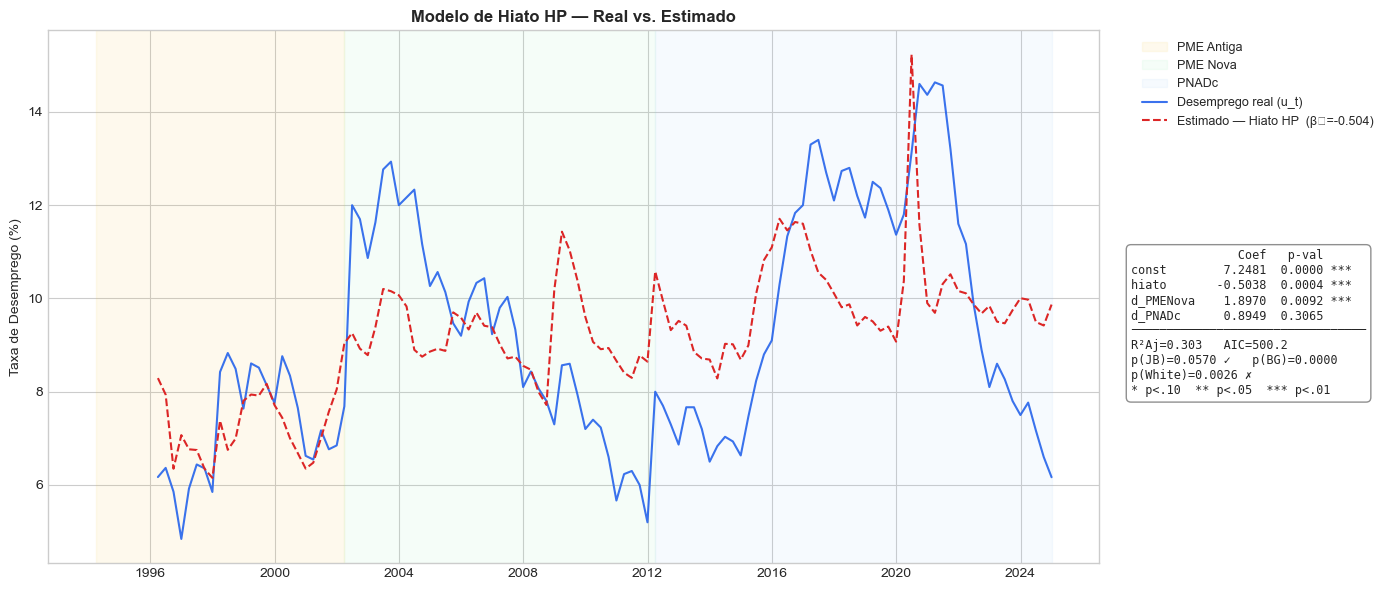

In [9]:
res_hp = estimar_modelo_hiato('hiato_hp', 'HP (λ=1600)')

fig, ax = plt.subplots(figsize=(14, 6))
sombrear_periodos(ax)
df_m = res_hp['df_m']
ax.plot(df_m.index, df_m['u_t'],           color=COR_PRINCIPAL, linewidth=1.5,
        label='Desemprego real (u_t)', alpha=0.9)
ax.plot(df_m.index, res_hp['modelo'].fittedvalues, color=COR_FITTED, linewidth=1.5,
        linestyle='--', label=f'Estimado — Hiato HP  (β₁={res_hp["beta1"]:.3f})')
ax.set_ylabel('Taxa de Desemprego (%)', fontsize=10)
ax.set_title('Modelo de Hiato HP — Real vs. Estimado', fontsize=12, fontweight='bold')
ax.legend(loc='upper left', bbox_to_anchor=(1.03, 1.0), fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(4))

_stars = lambda p: '***' if p < 0.01 else ('** ' if p < 0.05 else ('*  ' if p < 0.10 else '   '))
_label = {'const': 'const', 'hiato_hp': 'hiato', 'd_PMENova': 'd_PMENova', 'd_PNADc': 'd_PNADc'}
_lines = [f"{'':11}{'Coef':>8}  {'p-val':>6}"]
for _n in res_hp['modelo'].params.index:
    _lbl = _label.get(_n, _n)
    _lines.append(f"{_lbl:<11}{res_hp['modelo'].params[_n]:>8.4f}  {res_hp['modelo'].pvalues[_n]:>6.4f} {_stars(res_hp['modelo'].pvalues[_n])}")
_lines += [
    '─' * 33,
    f"R²Aj={res_hp['r2_adj']:.3f}   AIC={res_hp['aic']:.1f}",
    f"p(JB)={res_hp['jb_p']:.4f} {'✓' if res_hp['jb_p'] > 0.05 else '✗'}   p(BG)={res_hp['bg_p']:.4f}",
    f"p(White)={res_hp['white_p']:.4f} {'✓' if res_hp['white_p'] > 0.05 else '✗'}",
    '* p<.10  ** p<.05  *** p<.01',
]
ax.annotate('\n'.join(_lines), xy=(1.03, 0.45), xycoords='axes fraction',
            va='center', ha='left', fontsize=8.5, family='monospace',
            annotation_clip=False,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='gray', alpha=0.88))

plt.tight_layout()
plt.savefig('../figuras/fase3_modelo2/fig_11a_modelo_hiato_HP.png', dpi=150, bbox_inches='tight')
print("fig_11a salva")
plt.show()


MODELO HIATO — Hamilton (2018)
                            OLS Regression Results                            
Dep. Variable:                    u_t   R-squared:                       0.368
Model:                            OLS   Adj. R-squared:                  0.349
Method:                 Least Squares   F-statistic:                     11.35
Date:                Mon, 11 May 2026   Prob (F-statistic):           1.77e-06
Time:                        10:39:18   Log-Likelihood:                -216.91
No. Observations:                 105   AIC:                             441.8
Df Residuals:                     101   BIC:                             452.4
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const       

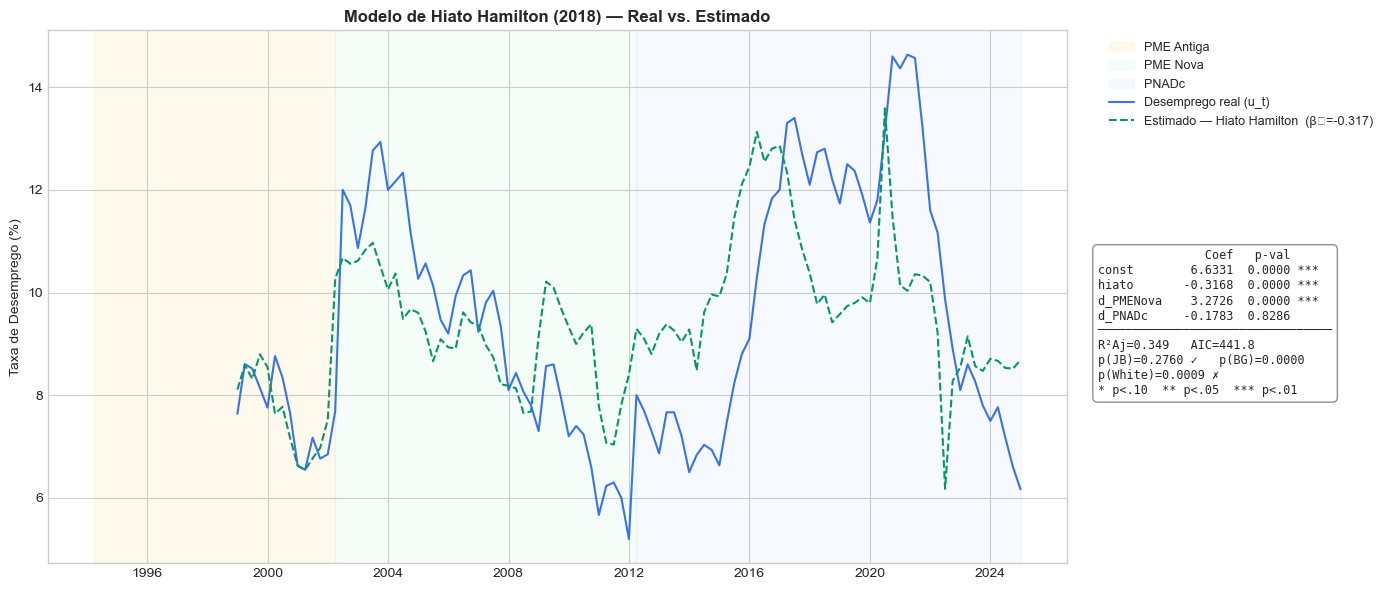

In [10]:
res_ham = estimar_modelo_hiato('hiato_hamilton', 'Hamilton (2018)')

fig, ax = plt.subplots(figsize=(14, 6))
sombrear_periodos(ax)
df_m = res_ham['df_m']
ax.plot(df_m.index, df_m['u_t'],           color=COR_PRINCIPAL, linewidth=1.5,
        label='Desemprego real (u_t)', alpha=0.9)
ax.plot(df_m.index, res_ham['modelo'].fittedvalues, color=COR_HAMILTN, linewidth=1.5,
        linestyle='--', label=f'Estimado — Hiato Hamilton  (β₁={res_ham["beta1"]:.3f})')
ax.set_ylabel('Taxa de Desemprego (%)', fontsize=10)
ax.set_title('Modelo de Hiato Hamilton (2018) — Real vs. Estimado', fontsize=12, fontweight='bold')
ax.legend(loc='upper left', bbox_to_anchor=(1.03, 1.0), fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(4))

_stars = lambda p: '***' if p < 0.01 else ('** ' if p < 0.05 else ('*  ' if p < 0.10 else '   '))
_label = {'const': 'const', 'hiato_hamilton': 'hiato', 'd_PMENova': 'd_PMENova', 'd_PNADc': 'd_PNADc'}
_lines = [f"{'':11}{'Coef':>8}  {'p-val':>6}"]
for _n in res_ham['modelo'].params.index:
    _lbl = _label.get(_n, _n)
    _lines.append(f"{_lbl:<11}{res_ham['modelo'].params[_n]:>8.4f}  {res_ham['modelo'].pvalues[_n]:>6.4f} {_stars(res_ham['modelo'].pvalues[_n])}")
_lines += [
    '─' * 33,
    f"R²Aj={res_ham['r2_adj']:.3f}   AIC={res_ham['aic']:.1f}",
    f"p(JB)={res_ham['jb_p']:.4f} {'✓' if res_ham['jb_p'] > 0.05 else '✗'}   p(BG)={res_ham['bg_p']:.4f}",
    f"p(White)={res_ham['white_p']:.4f} {'✓' if res_ham['white_p'] > 0.05 else '✗'}",
    '* p<.10  ** p<.05  *** p<.01',
]
ax.annotate('\n'.join(_lines), xy=(1.03, 0.45), xycoords='axes fraction',
            va='center', ha='left', fontsize=8.5, family='monospace',
            annotation_clip=False,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='gray', alpha=0.88))

plt.tight_layout()
plt.savefig('../figuras/fase3_modelo2/fig_11b_modelo_hiato_Hamilton.png', dpi=150, bbox_inches='tight')
print("fig_11b salva")
plt.show()


MODELO HIATO — Christiano-Fitzgerald (bandpass)
                            OLS Regression Results                            
Dep. Variable:                    u_t   R-squared:                       0.218
Model:                            OLS   Adj. R-squared:                  0.197
Method:                 Least Squares   F-statistic:                     6.354
Date:                Mon, 11 May 2026   Prob (F-statistic):           0.000512
Time:                        10:39:19   Log-Likelihood:                -254.32
No. Observations:                 116   AIC:                             516.6
Df Residuals:                     112   BIC:                             527.7
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
con

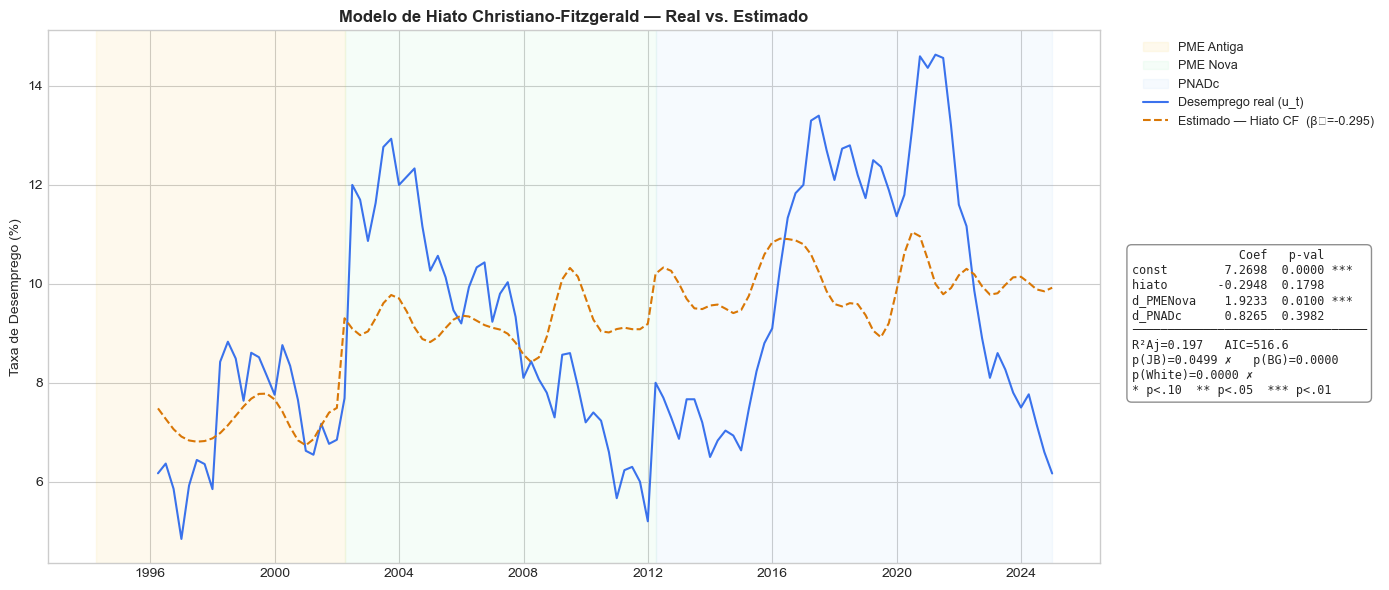

In [11]:
res_cf = estimar_modelo_hiato('hiato_cf', 'Christiano-Fitzgerald (bandpass)')

fig, ax = plt.subplots(figsize=(14, 6))
sombrear_periodos(ax)
df_m = res_cf['df_m']
ax.plot(df_m.index, df_m['u_t'],           color=COR_PRINCIPAL, linewidth=1.5,
        label='Desemprego real (u_t)', alpha=0.9)
ax.plot(df_m.index, res_cf['modelo'].fittedvalues, color=COR_CF, linewidth=1.5,
        linestyle='--', label=f'Estimado — Hiato CF  (β₁={res_cf["beta1"]:.3f})')
ax.set_ylabel('Taxa de Desemprego (%)', fontsize=10)
ax.set_title('Modelo de Hiato Christiano-Fitzgerald — Real vs. Estimado', fontsize=12, fontweight='bold')
ax.legend(loc='upper left', bbox_to_anchor=(1.03, 1.0), fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(4))

_stars = lambda p: '***' if p < 0.01 else ('** ' if p < 0.05 else ('*  ' if p < 0.10 else '   '))
_label = {'const': 'const', 'hiato_cf': 'hiato', 'd_PMENova': 'd_PMENova', 'd_PNADc': 'd_PNADc'}
_lines = [f"{'':11}{'Coef':>8}  {'p-val':>6}"]
for _n in res_cf['modelo'].params.index:
    _lbl = _label.get(_n, _n)
    _lines.append(f"{_lbl:<11}{res_cf['modelo'].params[_n]:>8.4f}  {res_cf['modelo'].pvalues[_n]:>6.4f} {_stars(res_cf['modelo'].pvalues[_n])}")
_lines += [
    '─' * 33,
    f"R²Aj={res_cf['r2_adj']:.3f}   AIC={res_cf['aic']:.1f}",
    f"p(JB)={res_cf['jb_p']:.4f} {'✓' if res_cf['jb_p'] > 0.05 else '✗'}   p(BG)={res_cf['bg_p']:.4f}",
    f"p(White)={res_cf['white_p']:.4f} {'✓' if res_cf['white_p'] > 0.05 else '✗'}",
    '* p<.10  ** p<.05  *** p<.01',
]
ax.annotate('\n'.join(_lines), xy=(1.03, 0.45), xycoords='axes fraction',
            va='center', ha='left', fontsize=8.5, family='monospace',
            annotation_clip=False,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='gray', alpha=0.88))

plt.tight_layout()
plt.savefig('../figuras/fase3_modelo2/fig_11c_modelo_hiato_CF.png', dpi=150, bbox_inches='tight')
print("fig_11c salva")
plt.show()


TABELA COMPARATIVA — 3 MODELOS DE HIATO
Modelo                                β₁   p(β₁)   R²Aj     AIC     JB  White
----------------------------------------------------------------------
HP (λ=1600)                      -0.5038   0.000  0.303   500.2      ✓      ✗
Hamilton (2018)                  -0.3168   0.000  0.349   441.8      ✓      ✗
Christiano-Fitzgerald (bandpass) -0.2948   0.180  0.197   516.6      ✗      ✗
fig_11_comparacao salva


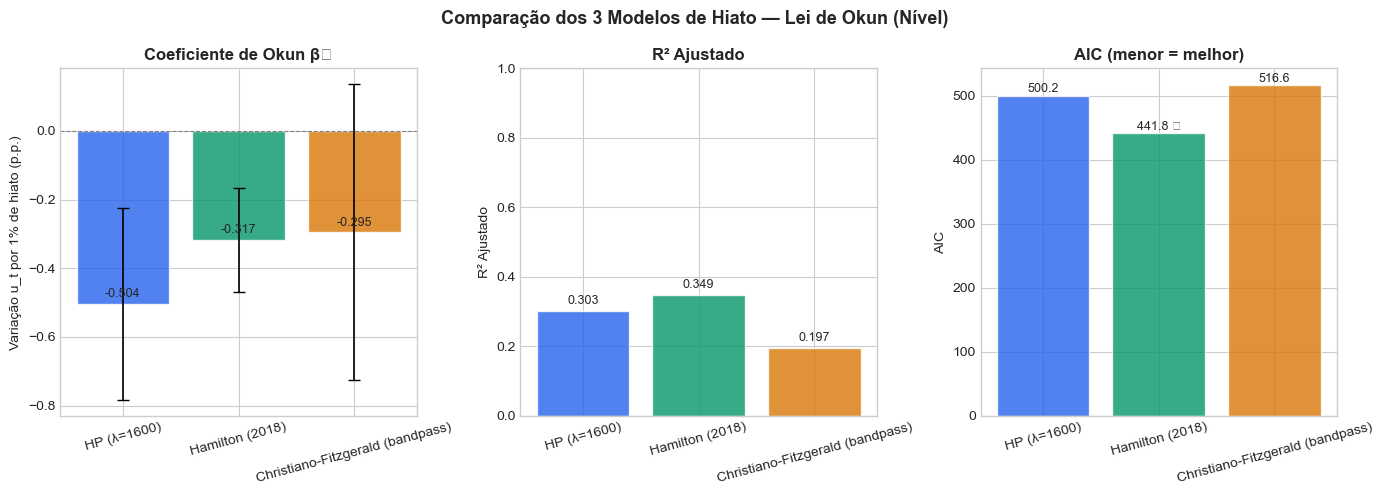

In [12]:
resultados = [res_hp, res_ham, res_cf]
nomes   = [r['label'] for r in resultados]

print("\n" + "="*70)
print("TABELA COMPARATIVA — 3 MODELOS DE HIATO")
print("="*70)
print(f"{'Modelo':<32} {'β₁':>7} {'p(β₁)':>7} {'R²Aj':>6} {'AIC':>7} {'JB':>6} {'White':>6}")
print("-"*70)
for r in resultados:
    jb_ok    = '✓' if r['jb_p']    > 0.05 else '✗'
    white_ok = '✓' if r['white_p'] > 0.05 else '✗'
    print(f"{r['label']:<32} {r['beta1']:>7.4f} {r['p_beta1']:>7.3f} "
          f"{r['r2_adj']:>6.3f} {r['aic']:>7.1f} {jb_ok:>6} {white_ok:>6}")

# Gráfico de comparação dos coeficientes β₁
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Comparação dos 3 Modelos de Hiato — Lei de Okun (Nível)',
             fontsize=13, fontweight='bold')

cores = [COR_PRINCIPAL, COR_HAMILTN, COR_CF]

# 1) β₁
ax = axes[0]
betas = [r['beta1'] for r in resultados]
erros = [r['modelo'].bse[r['df_m'].columns.tolist()[1]] for r in resultados]
bars  = ax.bar(nomes, betas, color=cores, alpha=0.8, edgecolor='white')
ax.errorbar(nomes, betas, yerr=[1.96*e for e in erros],
            fmt='none', color='black', capsize=4, linewidth=1.2)
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_title('Coeficiente de Okun β₁', fontweight='bold')
ax.set_ylabel('Variação u_t por 1% de hiato (p.p.)')
for bar, val in zip(bars, betas):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)
ax.tick_params(axis='x', labelrotation=15)

# 2) R² Ajustado
ax = axes[1]
r2s = [r['r2_adj'] for r in resultados]
bars = ax.bar(nomes, r2s, color=cores, alpha=0.8, edgecolor='white')
ax.set_title('R² Ajustado', fontweight='bold')
ax.set_ylabel('R² Ajustado')
ax.set_ylim(0, 1)
for bar, val in zip(bars, r2s):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)
ax.tick_params(axis='x', labelrotation=15)

# 3) AIC
ax = axes[2]
aics = [r['aic'] for r in resultados]
bars = ax.bar(nomes, aics, color=cores, alpha=0.8, edgecolor='white')
ax.set_title('AIC (menor = melhor)', fontweight='bold')
ax.set_ylabel('AIC')
best_aic = min(aics)
for bar, val in zip(bars, aics):
    label = f'{val:.1f}' + (' ★' if val==best_aic else '')
    ax.text(bar.get_x()+bar.get_width()/2, val + 0.3,
            label, ha='center', va='bottom', fontsize=9)
ax.tick_params(axis='x', labelrotation=15)

plt.tight_layout()
plt.savefig('../figuras/fase3_modelo2/fig_11_comparacao_modelos.png', dpi=150, bbox_inches='tight')
print("fig_11_comparacao salva")
plt.show()

Modelo selecionado (menor AIC = 441.8): Hamilton (2018)
fig_12 salva


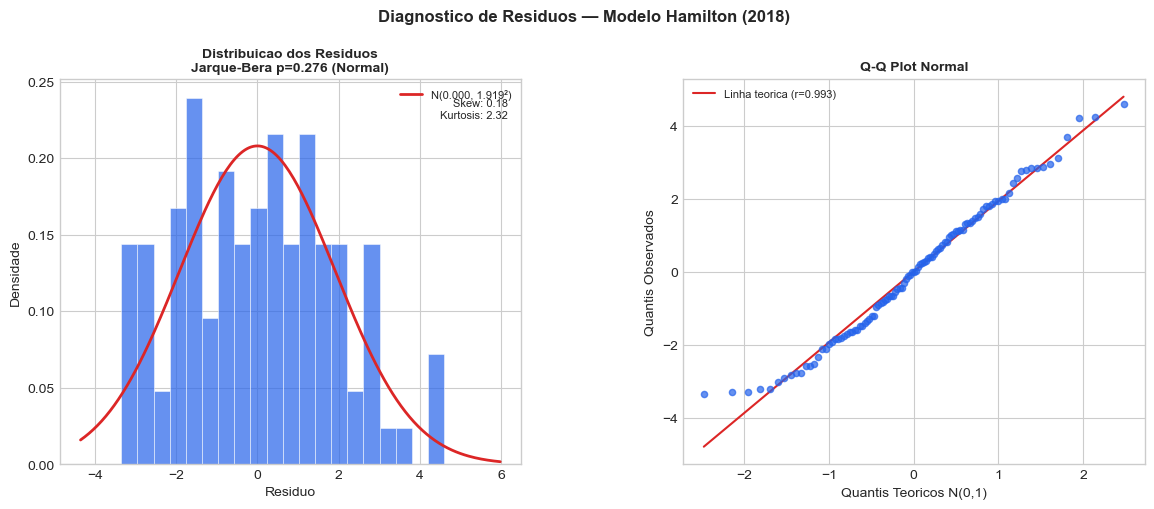

In [13]:
# Selecionar o melhor modelo pelo AIC
melhor = min([res_hp, res_ham, res_cf], key=lambda r: r['aic'])
print(f"Modelo selecionado (menor AIC = {melhor['aic']:.1f}): {melhor['label']}")

modelo_final = melhor['modelo']
residuos = modelo_final.resid

# ── DIAGNÓSTICO: histograma + Q-Q ──────────────────────────────────────────
fig = plt.figure(figsize=(14, 5))
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

ax1 = fig.add_subplot(gs[0])
xmin, xmax = residuos.min(), residuos.max()
x_vals = np.linspace(xmin*1.3, xmax*1.3, 200)
ax1.hist(residuos, bins=20, density=True, color=COR_PRINCIPAL, alpha=0.7,
         edgecolor='white', linewidth=0.5)
mu, sigma = residuos.mean(), residuos.std()
ax1.plot(x_vals, stats.norm.pdf(x_vals, mu, sigma), color=COR_FITTED, linewidth=2,
         label=f'N({mu:.3f}, {sigma:.3f}²)')
jb_s, jb_p, sk, ku = jarque_bera(residuos)
jb_label = "Normal" if jb_p > 0.05 else "Nao-Normal"
ax1.set_title(f'Distribuicao dos Residuos\nJarque-Bera p={jb_p:.3f} ({jb_label})',
              fontsize=10, fontweight='bold')
ax1.set_xlabel('Residuo'); ax1.set_ylabel('Densidade')
ax1.legend(fontsize=8)
ax1.text(0.97, 0.95, f'Skew: {sk:.2f}\nKurtosis: {ku:.2f}',
         transform=ax1.transAxes, ha='right', va='top', fontsize=8)

ax2 = fig.add_subplot(gs[1])
(osm, osr), (slope, intercept, r) = stats.probplot(residuos, dist='norm')
ax2.scatter(osm, osr, color=COR_PRINCIPAL, alpha=0.7, s=20, zorder=3)
x_line = np.array([min(osm), max(osm)])
ax2.plot(x_line, slope*x_line + intercept, color=COR_FITTED, linewidth=1.5,
         label=f'Linha teorica (r={r:.3f})')
ax2.set_title('Q-Q Plot Normal', fontsize=10, fontweight='bold')
ax2.set_xlabel('Quantis Teoricos N(0,1)'); ax2.set_ylabel('Quantis Observados')
ax2.legend(fontsize=8)

fig.suptitle(f'Diagnostico de Residuos — Modelo {melhor["label"]}',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figuras/fase3_modelo2/fig_12_residuos_diagnostico.png', dpi=150, bbox_inches='tight')
print("fig_12 salva")
plt.show()


In [14]:
# ── RESULTADO FINAL CONSOLIDADO ──────────────────────────────────────────────
print("\n" + "="*60)
print("COEFICIENTE DE OKUN — MODELO DE NÍVEL (HIATO)")
print("="*60)

for r in resultados:
    taxa_neutra = None  # Hiato=0 → u_t = β₀ + γ₁·d_PMENova + γ₂·d_PNADc
    print(f"\n{r['label']}")
    print(f"  β₁ (hiato→desemprego):      {r['beta1']:.4f}  (p={r['p_beta1']:.4f})")
    print(f"  β₀ (intercepto):            {r['beta0']:.4f}  (p={r['p_beta0']:.4f})")
    print(f"  γ₁ (step PME Nova):         {r['gamma1']:.4f}  (p={r['p_gamma1']:.4f})")
    print(f"  γ₂ (step PNADc):            {r['gamma2']:.4f}  (p={r['p_gamma2']:.4f})")
    print(f"  R² Ajustado: {r['r2_adj']:.3f}  |  AIC: {r['aic']:.1f}  |  BIC: {r['bic']:.1f}")
    print(f"  JB p={r['jb_p']:.3f} {'✓' if r['jb_p']>0.05 else '✗'}  |"
          f"  White p={r['white_p']:.3f} {'✓' if r['white_p']>0.05 else '✗'}")

print(f"\nModelo selecionado (menor AIC): {melhor['label']}")
print(f"Interpretação β₁ = {melhor['beta1']:.4f}:")
print(f"  Para cada 1 p.p. de hiato negativo (PIB abaixo do potencial),")
print(f"  a taxa de desemprego aumenta {abs(melhor['beta1']):.3f} p.p.")


COEFICIENTE DE OKUN — MODELO DE NÍVEL (HIATO)

HP (λ=1600)
  β₁ (hiato→desemprego):      -0.5038  (p=0.0004)
  β₀ (intercepto):            7.2481  (p=0.0000)
  γ₁ (step PME Nova):         1.8970  (p=0.0092)
  γ₂ (step PNADc):            0.8949  (p=0.3065)
  R² Ajustado: 0.303  |  AIC: 500.2  |  BIC: 511.2
  JB p=0.057 ✓  |  White p=0.003 ✗

Hamilton (2018)
  β₁ (hiato→desemprego):      -0.3168  (p=0.0000)
  β₀ (intercepto):            6.6331  (p=0.0000)
  γ₁ (step PME Nova):         3.2726  (p=0.0000)
  γ₂ (step PNADc):            -0.1783  (p=0.8286)
  R² Ajustado: 0.349  |  AIC: 441.8  |  BIC: 452.4
  JB p=0.276 ✓  |  White p=0.001 ✗

Christiano-Fitzgerald (bandpass)
  β₁ (hiato→desemprego):      -0.2948  (p=0.1798)
  β₀ (intercepto):            7.2698  (p=0.0000)
  γ₁ (step PME Nova):         1.9233  (p=0.0100)
  γ₂ (step PNADc):            0.8265  (p=0.3982)
  R² Ajustado: 0.197  |  AIC: 516.6  |  BIC: 527.7
  JB p=0.050 ✗  |  White p=0.000 ✗

Modelo selecionado (menor AIC): Hamilt